# Data Exploration and Visual Exploration Lab

In this lab, you will practice an exploratory workflow using a PM2.5 air-quality dataset from North Carolina.

This lab comes after the lessons on **Data Exploration** and **Visual Data Exploration**. The goal is not just to run code, but to decide what to inspect, interpret what you find, and document your reasoning.

## Learning goals

By the end of this lab, you should be able to:

- Load a CSV file into a Pandas dataframe.
- Inspect dataframe structure, column names, data types, and missing values.
- Explore numeric, categorical, and datetime fields.
- Summarize a numeric variable using descriptive statistics.
- Create exploratory visualizations using Pandas plotting methods.
- Compare plot types and choose appropriate visual tools for different questions.
- Write short interpretations of exploratory results.


## Part 1: Set Up the Session

Load the packages and define the folder paths used in this course project.


In [1]:
# Import packages: Path (from pathlib) and Pandas (as pd)
from pathlib import Path
import pandas as pd

In [2]:
# Set folder paths: project, raw, and processed
root_fldr = Path.cwd().parent
raw_fldr = root_fldr / 'data' / 'raw'
processed_fldr = root_fldr / 'data' / 'processed'

print('Root folder:', root_fldr)
print('Raw folder:', raw_fldr)
print("Processed folder:", processed_fldr)

Root folder: c:\ENV700
Raw folder: c:\ENV700\data\raw
Processed folder: c:\ENV700\data\processed


## Part 2: Load the Data
Read `EPAair_PM25_NC2025_raw.csv` into a dataframe named `pm25`.

When reading the file:

- Set `Site ID` to use the `category` data type.
- Parse `Date` as a datetime field.
- Use the date format `%m/%d/%Y`.

>Tip: See section 9 in the **M3-1** notebook.

In [9]:
# Read the CSV file into a dataframe named pm25.
raw_file = raw_fldr / 'EPAair_PM25_NC2025_raw.csv'
pm25 = pd.read_csv(raw_file,
                   dtype={"Site ID": "category"},
                   parse_dates=["Date"],
                   date_format='%m/%d/%Y')
pm25.dtypes

Date                              datetime64[us]
Source                                       str
Site ID                                 category
POC                                        int64
Daily Mean PM2.5 Concentration           float64
Units                                        str
Daily AQI Value                            int64
Local Site Name                              str
Daily Obs Count                            int64
Percent Complete                         float64
AQS Parameter Code                         int64
AQS Parameter Description                    str
Method Code                              float64
Method Description                           str
CBSA Code                                float64
CBSA Name                                    str
State FIPS Code                            int64
State                                        str
County FIPS Code                           int64
County                                       str
Site Latitude       

In [ ]:
# Display the first few rows.
pm25.head()

,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
10179,2025-12-27,AQS,371830021,3,8.9,ug/m3 LC,49,Triple Oak,1,100.0,...,209.0,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,39580.0,"Raleigh, NC",37,North Carolina,183,Wake,35.8652,-78.8197
10180,2025-12-28,AQS,371830021,3,4.7,ug/m3 LC,26,Triple Oak,1,100.0,...,209.0,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,39580.0,"Raleigh, NC",37,North Carolina,183,Wake,35.8652,-78.8197
10181,2025-12-29,AQS,371830021,3,5.2,ug/m3 LC,29,Triple Oak,1,100.0,...,209.0,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,39580.0,"Raleigh, NC",37,North Carolina,183,Wake,35.8652,-78.8197
10182,2025-12-30,AQS,371830021,3,4.2,ug/m3 LC,23,Triple Oak,1,100.0,...,209.0,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,39580.0,"Raleigh, NC",37,North Carolina,183,Wake,35.8652,-78.8197
10183,2025-12-31,AQS,371830021,3,4.4,ug/m3 LC,24,Triple Oak,1,100.0,...,209.0,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,39580.0,"Raleigh, NC",37,North Carolina,183,Wake,35.8652,-78.8197


### Reflection

In one or two sentences, describe what a single row in this dataset appears to represent.

**Your answer:**
Data quality at a site on a given day


## Part 3: Inspect the Dataframe Structure

Use dataframe attributes and methods to answer the following questions.

- How many rows and columns are in the dataframe?
- What are the column names?
- What data type is assigned to each column?
- Which columns are numeric?
- Which columns are categorical or text-like?
- Which column is datetime?


In [12]:
# How many rows and columns are in the dataframe?
pm25.shape

(10184, 22)

In [13]:
# What are the column names?
pm25.columns

Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'State FIPS Code', 'State', 'County FIPS Code', 'County',
       'Site Latitude', 'Site Longitude'],
      dtype='str')

In [14]:
# Display data types and non-null counts for all the columns?
pm25.info()

<class 'pandas.DataFrame'>
RangeIndex: 10184 entries, 0 to 10183
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Date                            10184 non-null  datetime64[us]
 1   Source                          10184 non-null  str           
 2   Site ID                         10184 non-null  category      
 3   POC                             10184 non-null  int64         
 4   Daily Mean PM2.5 Concentration  10184 non-null  float64       
 5   Units                           10184 non-null  str           
 6   Daily AQI Value                 10184 non-null  int64         
 7   Local Site Name                 10184 non-null  str           
 8   Daily Obs Count                 10184 non-null  int64         
 9   Percent Complete                10184 non-null  float64       
 10  AQS Parameter Code              10184 non-null  int64         
 11  AQS Parameter

### Interpretation

Answer the following based on the output above.

1. How many observations are in the dataset?  
2. How many variables are in the dataset?  
3. Which variable uses a datetime data type?  
4. Why should `Site ID` be stored as a category instead of as a number?  

**Your answers:**


1. 10184 observations in the data set
2. 22 variable in the dataset
3. "Date" uses the datetime data type
4. Site ID is using number to describe the site, but is not a continuous variable

## Part 4: Check for Missing Values

Missing values are important to identify early because they can affect summaries, plots, and later analysis.


In [15]:
# Count missing values in each column.
missing_counts = pm25.isna().sum()
missing_counts

Date                                 0
Source                               0
Site ID                              0
POC                                  0
Daily Mean PM2.5 Concentration       0
Units                                0
Daily AQI Value                      0
Local Site Name                      0
Daily Obs Count                      0
Percent Complete                     0
AQS Parameter Code                   0
AQS Parameter Description            0
Method Code                         56
Method Description                  56
CBSA Code                         1500
CBSA Name                         1500
State FIPS Code                      0
State                                0
County FIPS Code                     0
County                               0
Site Latitude                        0
Site Longitude                       0
dtype: int64

In [19]:
# Optional: Calculate the percentage of records missing in each column.
# Hint: divide the missing-value counts by the number of rows and multiply by 100.

# Your code here
missing_percent = pm25.isna().mean().sort_values(ascending=False) * 100
missing_percent

CBSA Code                         14.728987
CBSA Name                         14.728987
Method Description                 0.549882
Method Code                        0.549882
Date                               0.000000
Source                             0.000000
Units                              0.000000
Daily Mean PM2.5 Concentration     0.000000
POC                                0.000000
Site ID                            0.000000
Percent Complete                   0.000000
Daily Obs Count                    0.000000
Daily AQI Value                    0.000000
Local Site Name                    0.000000
AQS Parameter Code                 0.000000
AQS Parameter Description          0.000000
State FIPS Code                    0.000000
State                              0.000000
County FIPS Code                   0.000000
County                             0.000000
Site Latitude                      0.000000
Site Longitude                     0.000000
dtype: float64

### Interpretation

1. Which columns, if any, contain missing values?  
2. Are the missing values likely to affect the initial exploration? Why or why not?  

**Your answers:**


1. CBSA Code and CBSA Name are both missing the most data. Method Description and Method Code are both also missing data. 
2. For CBSA code and name, because we have other location data, that may be able to make up for the missing data here, such as county, Site ID and Longitude and Latitude. Method may not impact the initial exploration, but we may want to keep in mind that some are missing that as we examine the data further.

## Part 5: Explore a Numeric Variable

The main numeric variable in this dataset is daily mean PM2.5 concentration.

Use the column:

```python
"Daily Mean PM2.5 Concentration"
```


In [21]:
# Store the concentration column name in a shorter variable for reuse.
conc_col = "Daily Mean PM2.5 Concentration"

In [22]:
# Display descriptive statistics for daily mean PM2.5 concentration.
pm25[conc_col].describe()

count    10184.000000
mean         7.097840
std          3.700242
min         -1.800000
25%          4.500000
50%          6.500000
75%          9.025000
max         43.700000
Name: Daily Mean PM2.5 Concentration, dtype: float64

In [25]:
# Compute the mean and median separately.
mean_pm25 = pm25[conc_col].mean()
median_pm25 = pm25[conc_col].median()

In [26]:
# Print the values
print("Mean PM2.5:", mean_pm25)
print("Median PM2.5:", median_pm25)

Mean PM2.5: 7.097839748625294
Median PM2.5: 6.5


* Use the [quantiles](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.quantile.html) method to display the quantiles of the dataframe. Adjust the command to show the highest and lowest 20th percentile (4.1 and 9.7, respectively).

In [28]:
# Compute selected quantiles.
pm25[conc_col].quantile([0.2, 0.8])

0.2    4.1
0.8    9.7
Name: Daily Mean PM2.5 Concentration, dtype: float64

### Interpretation

1. What is the minimum daily mean PM2.5 concentration?  
2. What is the maximum daily mean PM2.5 concentration?  
3. Is the mean larger or smaller than the median?  
4. What might the relationship between the mean and median suggest about the shape of the distribution?  
5. In what units are PM2.5 concentrations reported?  

**Your answers:**


1. Minimum daily mean PM2.5 concentration is -1.8.
2. Maximum daily mean PM2.5 concentration is 43.7.
3. The mean is larger than the median.
4. This suggests that the distribution is right-skewed, with more outliers on the higher end of the data.
5. PM2.5 concentrations are reported in ppm.

## Part 6: Explore Categorical Variables

Categorical variables often describe groups, locations, sources, or measurement types.

Start with `Site ID` and `County`.


In [31]:
# How many unique monitoring sites are included?
pm25["Site ID"].nunique()

26

In [32]:
# List the unique Site ID categories?
pm25["Site ID"].unique()

['370110002', '370210034', '370350004', '370510009', '370570002', ..., '371590021', '371730002', '371730007', '371830014', '371830021']
Length: 26
Categories (26, str): ['370110002', '370210034', '370350004', '370510009', ..., '371730002', '371730007', '371830014', '371830021']

In [37]:
# Count records by county.
pm25["County"].value_counts()

County
Mecklenburg    1226
Forsyth         895
Wake            840
Buncombe        762
New Hanover     709
Catawba         695
Swain           614
Durham          585
Davidson        398
Pitt            362
Guilford        360
Mitchell        359
Edgecombe       358
Cumberland      357
Montgomery      354
Northampton     353
Johnston        352
Rowan           352
Avery            87
Hyde             86
Haywood          80
Name: count, dtype: int64

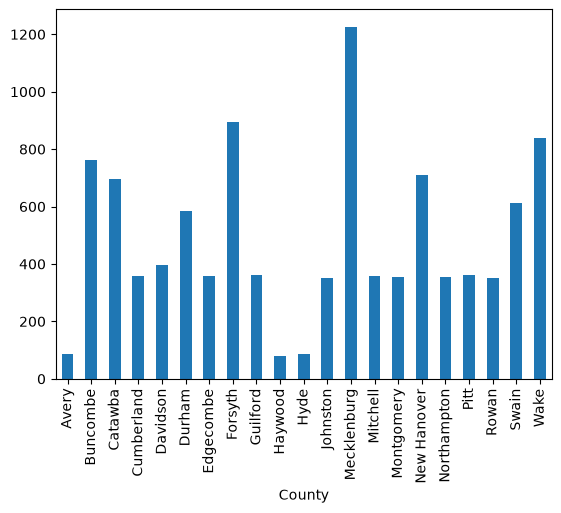

In [42]:
# Create a simple bar plot showing the number of records by county.
# Hint: combine value_counts() with Pandas .plot(kind='bar').
pm25["County"].value_counts().sort_index(ascending=True).plot(kind='bar');


### Interpretation

1. How many different monitoring sites are included?  
2. Which source contributes the most observations?  
3. Are observations balanced across sources?  
4. Why might an unbalanced number of observations matter when comparing groups?  

**Your answers:**


1. 26 monitoring sites are included in the study.
2. Mecklenberg county contributes the most observations.
3. Observations rae not balanced across soures; some have less than 200 and some have over 1000 observations.
4. Those sources might have an outsized impact on the analysis due to the high amounts of sampling. 

## Part 7: Explore the Datetime Field

Datetime fields have useful sub-components such as year, month, day, and day of week.


In [45]:
# What date range is covered by the dataset? Print the earliest and latest dates in the dataset
print("Earliest:", pm25["Date"].min())
print("Latest:", pm25["Date"].max())

Earliest: 2025-01-01 00:00:00
Latest: 2025-12-31 00:00:00


In [49]:
# Count observations by month.
pm25['Date'].dt.month.value_counts().sort_index()

Date
1     856
2     751
3     837
4     825
5     888
6     861
7     896
8     908
9     850
10    793
11    851
12    868
Name: count, dtype: int64

In [51]:
# Optional: Create a month column for later exploration.
pm25["Month"] = pm25["Date"].dt.month
pm25["Month"].head()

0    1
1    1
2    1
3    1
4    1
Name: Month, dtype: int32

### Interpretation

1. What time period is covered by this dataset?  
2. Does the dataset appear to cover a full calendar year?  
3. Are observations evenly distributed across months?  

**Your answers:**


1. This time period covers the full calendar year of 2025.
2. There are observations in each month, so it appears this dataset covers the full calendar year.
3. Observations are not evenly distributed across months. August has the most observations and February has the fewest (as expected). Though there is variety there are all within a relatively small range.

## Part 8: Visualize the Distribution of PM2.5

Start by visualizing the distribution of daily mean PM2.5 concentrations.


<Axes: ylabel='Frequency'>

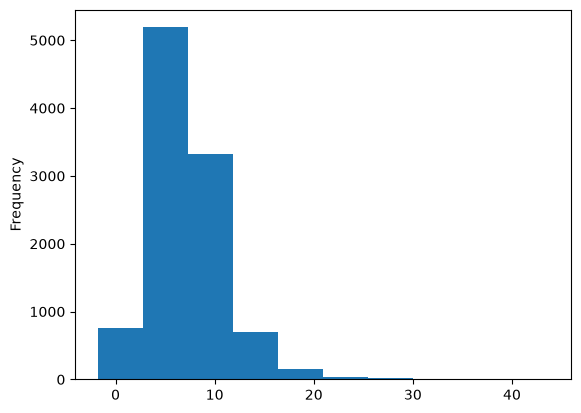

In [52]:
# Create a histogram of daily mean PM2.5 concentration using Pandas plotting.
# Hint: select the concentration Series and use .plot(kind='hist').
pm25[conc_col].plot(kind='hist')


<Axes: >

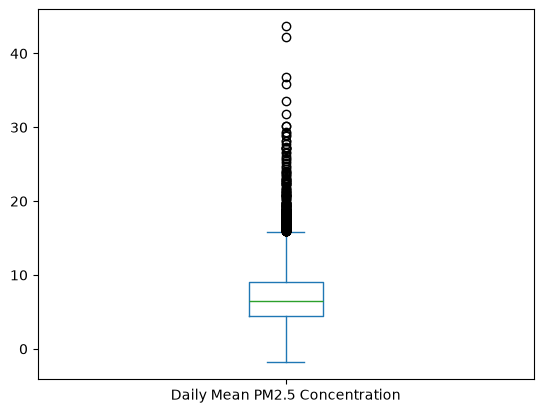

In [53]:
# Create a box plot of daily mean PM2.5 concentration using Pandas plotting.
# Hint: select the concentration Series and use .plot(kind='box').
pm25[conc_col].plot(kind='box')


### Interpretation

1. Is the distribution symmetric, left-skewed, or right-skewed?  
2. Are there possible outliers?  
3. Which plot made it easier to see the overall shape of the distribution?  
4. Which plot made it easier to identify unusually high values?  

**Your answers:**


1. The distribution is right skewed, with a right hand tail of data.
2. There appear to be a few possible outliers above 40 ppm.
3. The histogram made it easier to see the overall shape of the distribution.
4. The box plot made it easier to identify unusually high values.

## Part 9: Compare PM2.5 by Source

Now compare daily mean PM2.5 concentration across measurement sources.

Create several visualizations, then decide which one is most useful for comparison.

>Below is code to transform the data such that concentration values are separated into different columns based on their source type ("AQS" or "AirNow"). We'll examine this code later, but you will need this format to produce the KDE plot.

In [58]:
#Transform data so concentration values are in separate columns by Source
pm25_wide = pm25.pivot_table(
    index = ['Site ID','Date'],
    columns = 'Source',
    values = conc_col,
    aggfunc = 'mean'
).reset_index()

#Show the data
pm25_wide.head(10)

Source,Site ID,Date,AQS,AirNow
0,370110002,2025-01-01,0.7,NaN
1,370110002,2025-01-04,1.2,NaN
2,370110002,2025-01-07,1.5,NaN
3,370110002,2025-01-10,4.2,NaN
4,370110002,2025-01-13,5.0,NaN
5,370110002,2025-01-19,8.5,NaN
6,370110002,2025-01-22,3.2,NaN
7,370110002,2025-01-25,3.2,NaN
8,370110002,2025-01-28,2.3,NaN
9,370110002,2025-01-31,7.4,NaN


<Axes: ylabel='Density'>

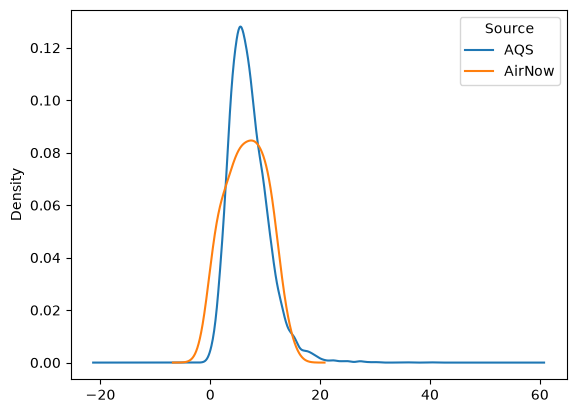

In [59]:
# Create overlaid density (KDE) curves comparing PM2.5 concentration by source. 
# Use Pandas .plot(kind='kde').

pm25_wide[['AQS', 'AirNow']].plot(kind='kde')

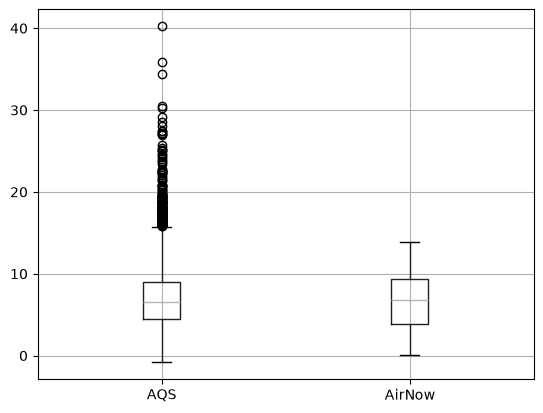

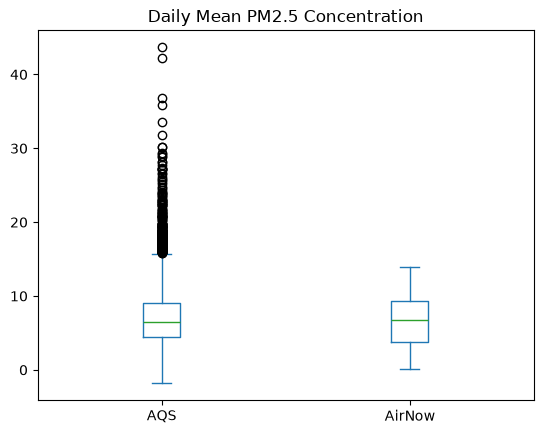

In [66]:
# Create a box plot comparing PM2.5 concentration by source.
# Hint: use Pandas .plot(kind='box', by='Source') or DataFrame.boxplot().
pm25_wide[["AQS", "AirNow"]].boxplot()

pm25[[conc_col, "Source"]].plot(kind='box', by='Source');

<Axes: ylabel='Frequency'>

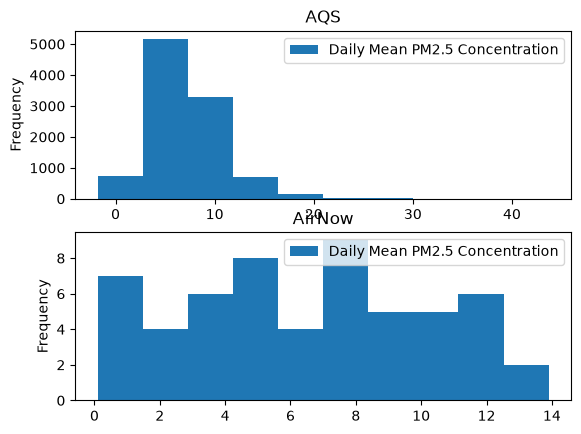

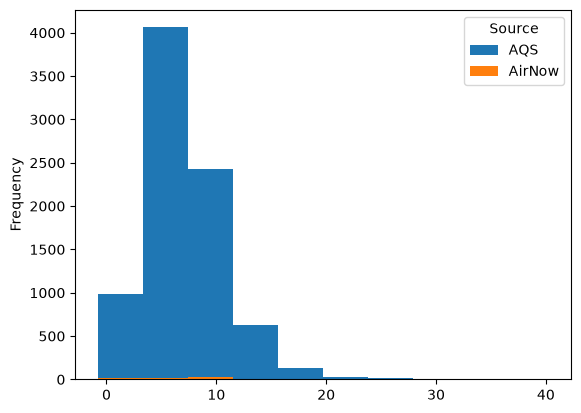

In [68]:
# Create histograms of PM2.5 concentration for each source.
# Use Pandas plotting to compare the distributions. You may create separate plots or overlay them.
pm25[[conc_col, "Source"]].plot(kind='hist', by='Source')
pm25_wide[["AQS", "AirNow"]].plot(kind='hist')

## Part 11: Data Exploration Checklist

Use this checklist when exploring a new dataset.

- [ ] Load the data and confirm it imported correctly.
- [ ] Examine rows, columns, and column names.
- [ ] Inspect data types.
- [ ] Identify missing values.
- [ ] Summarize numeric variables.
- [ ] Examine categorical variables.
- [ ] Explore datetime variables.
- [ ] Visualize distributions.
- [ ] Compare groups when relevant.
- [ ] Document unusual observations.
- [ ] Write short conclusions in plain language.
